
Training with SGD optimizer...
Epoch 1: Train Loss=0.6680, Val Loss=0.6616, Val Acc=0.7739
Epoch 2: Train Loss=0.6530, Val Loss=0.6505, Val Acc=0.7739
Epoch 3: Train Loss=0.6453, Val Loss=0.6408, Val Acc=0.7739
Epoch 4: Train Loss=0.6318, Val Loss=0.6315, Val Acc=0.7739
Epoch 5: Train Loss=0.6207, Val Loss=0.6227, Val Acc=0.7739
Epoch 6: Train Loss=0.6172, Val Loss=0.6151, Val Acc=0.7739
Epoch 7: Train Loss=0.6095, Val Loss=0.6080, Val Acc=0.7739
Epoch 8: Train Loss=0.6063, Val Loss=0.6017, Val Acc=0.7739
Epoch 9: Train Loss=0.6048, Val Loss=0.5962, Val Acc=0.7739
Epoch 10: Train Loss=0.5962, Val Loss=0.5907, Val Acc=0.7739
Epoch 11: Train Loss=0.5828, Val Loss=0.5850, Val Acc=0.7739
Epoch 12: Train Loss=0.5765, Val Loss=0.5798, Val Acc=0.7739
Epoch 13: Train Loss=0.5761, Val Loss=0.5753, Val Acc=0.7739
Epoch 14: Train Loss=0.5802, Val Loss=0.5713, Val Acc=0.7739
Epoch 15: Train Loss=0.5681, Val Loss=0.5672, Val Acc=0.7739
Epoch 16: Train Loss=0.5552, Val Loss=0.5632, Val Acc=0.7739
E

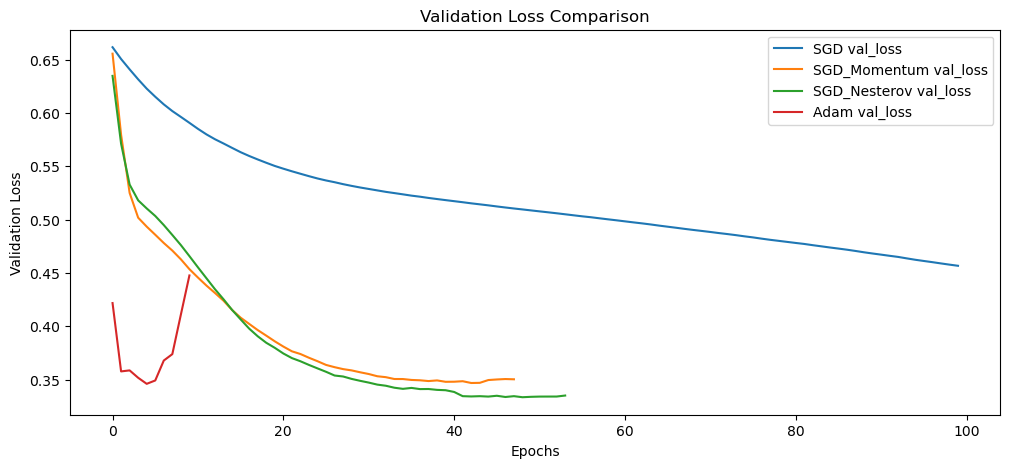

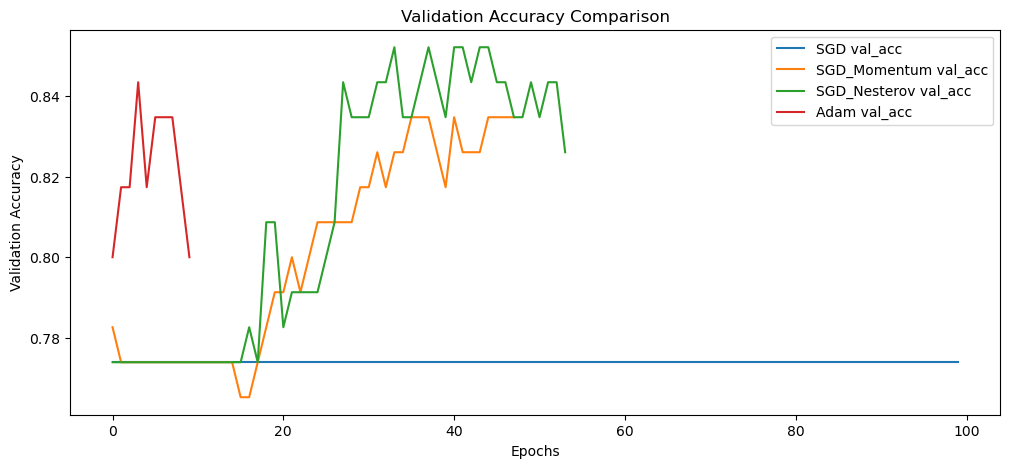


Best Optimizer: SGD_Nesterov
Accuracy: 0.8173913043478261
Precision: 0.5909090909090909
Recall: 0.52
F1: 0.5531914893617021
Confusion Matrix:
 [[81  9]
 [12 13]]


In [14]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import time
import os
data_path = r"C:\Users\23adsb47\Documents\bank"
if os.path.isdir(data_path):
    files = os.listdir(data_path)
    if "bank-additional-full.csv" in files:
        dataset_path = os.path.join(data_path, "bank-additional-full.csv")
    elif "bank-additional.csv" in files:
        dataset_path = os.path.join(data_path, "bank-additional.csv")
    elif "bank.csv" in files:
        dataset_path = os.path.join(data_path, "bank.csv")
    else:
        raise FileNotFoundError("No valid bank dataset file found in folder.")
else:
    dataset_path = data_path
df = pd.read_csv(dataset_path, sep=";")
df = df.replace("unknown", np.nan).dropna()
X = df.drop("y", axis=1)
y = df["y"].map({"yes":1, "no":0}).values
categorical_cols = X.select_dtypes(include=["object"]).columns
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
X_cat = encoder.fit_transform(X[categorical_cols])
numerical_cols = X.select_dtypes(include=["int64","float64"]).columns
scaler = StandardScaler()
X_num = scaler.fit_transform(X[numerical_cols])
X_processed = np.hstack([X_num, X_cat])
X_train, X_temp, y_train, y_temp = train_test_split(X_processed, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)
def to_tensor_dataset(X, y):
    return TensorDataset(torch.tensor(X, dtype=torch.float32),
                         torch.tensor(y, dtype=torch.float32).unsqueeze(1))
train_ds = to_tensor_dataset(X_train, y_train)
val_ds = to_tensor_dataset(X_val, y_val)
test_ds = to_tensor_dataset(X_test, y_test)
class BankNN(nn.Module):
    def __init__(self, input_dim):
        super(BankNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.drop1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, 64)
        self.drop2 = nn.Dropout(0.2)
        self.fc3 = nn.Linear(64, 1)
    
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.drop1(x)
        x = F.relu(self.fc2(x))
        x = self.drop2(x)
        x = torch.sigmoid(self.fc3(x))
        return x
def train_model(optimizer_name, optimizer_params, batch_size=64, patience=5):
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    model = BankNN(X_train.shape[1])
    criterion = nn.BCELoss()
    optimizer = getattr(torch.optim, optimizer_name)(model.parameters(), **optimizer_params)

    best_val_loss = float("inf")
    patience_counter = 0
    history = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}
    start_time = time.time() 
    for epoch in range(100): 
        model.train()
        train_losses, train_preds, train_targets = [], [], []
        for xb, yb in train_loader:
            optimizer.zero_grad()
            outputs = model(xb)
            loss = criterion(outputs, yb)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())
            train_preds.extend(outputs.detach().numpy())
            train_targets.extend(yb.numpy())
        train_acc = accuracy_score(train_targets, np.round(train_preds))
        model.eval()
        val_losses, val_preds, val_targets = [], [], []
        with torch.no_grad():
            for xb, yb in val_loader:
                outputs = model(xb)
                loss = criterion(outputs, yb)
                val_losses.append(loss.item())
                val_preds.extend(outputs.numpy())
                val_targets.extend(yb.numpy())
        val_acc = accuracy_score(val_targets, np.round(val_preds))
        val_loss = np.mean(val_losses)
        history["train_loss"].append(np.mean(train_losses))
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        print(f"Epoch {epoch+1}: Train Loss={np.mean(train_losses):.4f}, Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_model_state = model.state_dict()
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break
    total_time = time.time() - start_time
    model.load_state_dict(best_model_state)
    return model, history, total_time
optimizers = {
    "SGD": {"lr":0.01},
    "SGD_Momentum": {"lr":0.01, "momentum":0.9},
    "SGD_Nesterov": {"lr":0.01, "momentum":0.9, "nesterov":True},
    "Adam": {"lr":0.01},  # as proxy for mini-batch gradient descent
}
results = {}
for name, params in optimizers.items():
    print(f"\nTraining with {name} optimizer...")
    model, history, t = train_model("SGD" if "SGD" in name else "Adam", params)
    results[name] = {"history":history, "time":t, "model":model}
plt.figure(figsize=(12,5))
for name, res in results.items():
    plt.plot(res["history"]["val_loss"], label=f"{name} val_loss")
plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.legend()
plt.title("Validation Loss Comparison")
plt.show()
plt.figure(figsize=(12,5))
for name, res in results.items():
    plt.plot(res["history"]["val_acc"], label=f"{name} val_acc")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.title("Validation Accuracy Comparison")
plt.show()
best_optimizer = max(results.items(), key=lambda kv: max(kv[1]["history"]["val_acc"]))
best_model = best_optimizer[1]["model"]
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)
test_preds, test_targets = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        outputs = best_model(xb)
        test_preds.extend(outputs.numpy())
        test_targets.extend(yb.numpy())
test_preds = np.round(test_preds)
print("\nBest Optimizer:", best_optimizer[0])
print("Accuracy:", accuracy_score(test_targets, test_preds))
print("Precision:", precision_score(test_targets, test_preds))
print("Recall:", recall_score(test_targets, test_preds))
print("F1:", f1_score(test_targets, test_preds))
print("Confusion Matrix:\n", confusion_matrix(test_targets, test_preds))


In [7]:
pip install torch torchvision torchaudio


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
